# Recurrent Grad-CAM S3D — version alignée pour comparaison

Ce notebook implémente la variation **Recurrent Grad-CAM** avec backbone vidéo **S3D** et module temporel **LSTM**.

L'objectif est de comparer cette méthode avec l'approche proposée **Attention-Gated Recurrent Grad-CAM**, en gardant une logique d'évaluation proche, mais sans ajouter artificiellement des composantes qui n'existent pas dans cette variation.

Composantes présentes :
- Backbone vidéo S3D ;
- Module temporel LSTM ;
- Grad-CAM spatio-temporel ;
- Importance temporelle dérivée de la heatmap ;
- Explication dynamique par optical flow pondéré par Grad-CAM ;
- Deletion / Insertion spatio-temporelles ;
- Stabilité temporelle ;
- Motion proxy.

Composantes absentes volontairement :
- Spatial Gate ;
- Alpha/Beta Gate ;
- contraintes XAI propres à l'approche proposée ;
- diagnostic de porte temporelle.


"""
Recurrent Grad-CAM baseline for video XAI on UCF101 (Kaggle)
Backbone: S3D/I3D-like video CNN or optional R3D-18.
Temporal model: LSTM over frame-level CNN features.
Goal: fair comparison against Attention-Gated Transformer Grad-CAM.

Dataset expected layout:
/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train/<class>/*.avi
/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val/<class>/*.avi
/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/<class>/*.avi

Outputs:
- checkpoints in ./xai_outputs_recurrent
- explanation videos with heatmap overlay + red border on important frames
- full split evaluation CSV and summaries
"""

In [1]:


import os
import cv2
import json
import math
import random
import shutil
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.video import s3d, S3D_Weights, r3d_18, R3D_18_Weights

try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

## 1. Configuration

In [2]:
# 1. Configuration

In [3]:
@dataclass
class CFG:
    dataset_root: str = "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition"
    backbone_name: str = "s3d"       # "s3d" = I3D-like; "r3d_18" optional
    pretrained: bool = True
    num_classes: int = 101

    clip_len: int = 32
    frame_size: int = 224
    batch_size: int = 2              # safe for Kaggle T4; raise if memory allows
    num_workers: int = 2
    epochs: int = 10
    lr: float = 1e-4
    weight_decay: float = 1e-4

    lstm_hidden: int = 256
    lstm_layers: int = 1
    lstm_bidirectional: bool = True
    dropout: float = 0.4

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42
    output_dir: str = "./xai_outputs_recurrent"

    # evaluation settings
    top_temporal_ratio: float = 0.25
    eval_steps: int = 8


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_split_dirs(cfg: CFG):
    return {
        "train": os.path.join(cfg.dataset_root, "train"),
        "val": os.path.join(cfg.dataset_root, "val"),
        "test": os.path.join(cfg.dataset_root, "test"),
    }

## 2. Dataset UCF101 folder loader

In [4]:
# 2. Dataset UCF101 folder loader

In [5]:
class UCF101VideoFolderDataset(Dataset):
    def __init__(
        self,
        root_dir: str,
        clip_len: int = 32,
        frame_size: int = 224,
        train: bool = False,
        class_to_idx: Optional[Dict[str, int]] = None,
    ):
        self.root_dir = root_dir
        self.clip_len = clip_len
        self.frame_size = frame_size
        self.train = train

        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = class_to_idx if class_to_idx is not None else {c: i for i, c in enumerate(classes)}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

        exts = (".avi", ".mp4", ".mov", ".mkv")
        self.samples = []
        for cls in classes:
            cls_dir = os.path.join(root_dir, cls)
            for f in sorted(os.listdir(cls_dir)):
                if f.lower().endswith(exts):
                    self.samples.append((os.path.join(cls_dir, f), self.class_to_idx[cls], cls))

        self.normalize = transforms.Normalize(
            mean=[0.43216, 0.394666, 0.37645],
            std=[0.22803, 0.22145, 0.216989],
        )

    def __len__(self):
        return len(self.samples)

    def _read_video(self, path: str) -> List[np.ndarray]:
        cap = cv2.VideoCapture(path)
        frames = []
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()
        return frames

    def _sample_indices(self, n: int) -> np.ndarray:
        if n <= 0:
            return np.zeros(self.clip_len, dtype=np.int64)
        if n >= self.clip_len:
            if self.train:
                start = random.randint(0, max(0, n - self.clip_len))
                return np.arange(start, start + self.clip_len)
            return np.linspace(0, n - 1, self.clip_len).astype(np.int64)
        return np.linspace(0, n - 1, self.clip_len).astype(np.int64)

    def _preprocess(self, frames: List[np.ndarray]) -> Tuple[torch.Tensor, torch.Tensor]:
        idx = self._sample_indices(len(frames))
        sampled = []
        original = []
        for i in idx:
            if len(frames) == 0:
                fr = np.zeros((self.frame_size, self.frame_size, 3), dtype=np.uint8)
            else:
                fr = frames[int(i)]
            original.append(fr.copy())
            fr = cv2.resize(fr, (self.frame_size, self.frame_size))
            if self.train and random.random() < 0.5:
                fr = cv2.flip(fr, 1)
            sampled.append(fr)

        arr = np.stack(sampled).astype(np.float32) / 255.0
        x = torch.from_numpy(arr).permute(3, 0, 1, 2)  # C,T,H,W
        for t in range(x.shape[1]):
            x[:, t] = self.normalize(x[:, t])

        original_resized = np.stack([cv2.resize(fr, (self.frame_size, self.frame_size)) for fr in original])
        original_tensor = torch.from_numpy(original_resized).permute(3, 0, 1, 2).float() / 255.0
        return x, original_tensor

    def __getitem__(self, idx):
        path, y, cls = self.samples[idx]
        frames = self._read_video(path)
        x, original = self._preprocess(frames)
        return {
            "video": x,
            "original": original,
            "label": torch.tensor(y, dtype=torch.long),
            "path": path,
            "class_name": cls,
        }


def build_loaders(cfg: CFG):
    split_dirs = get_split_dirs(cfg)
    train_ds = UCF101VideoFolderDataset(split_dirs["train"], cfg.clip_len, cfg.frame_size, train=True)
    val_ds = UCF101VideoFolderDataset(split_dirs["val"], cfg.clip_len, cfg.frame_size, train=False, class_to_idx=train_ds.class_to_idx)
    test_ds = UCF101VideoFolderDataset(split_dirs["test"], cfg.clip_len, cfg.frame_size, train=False, class_to_idx=train_ds.class_to_idx)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
    print(f"Train videos: {len(train_ds)} | Val videos: {len(val_ds)} | Test videos: {len(test_ds)}")
    print(f"Classes: {len(train_ds.class_to_idx)}")
    return train_loader, val_loader, train_ds, val_ds, test_ds

## 3. Model: CNN backbone + LSTM

In [6]:
# 3. Model: CNN backbone + LSTM

In [7]:
class RecurrentGradCAMVideoModel(nn.Module):
    """
    Recurrent Grad-CAM baseline.
    The model uses a video CNN backbone to extract spatio-temporal features,
    pools spatially to get a sequence, then uses LSTM for temporal modelling.

    It is NOT attention-gated by design. Temporal importance is extracted post-hoc
    using gradients w.r.t. the LSTM input sequence and Grad-CAM over CNN features.
    """
    def __init__(self, num_classes=101, backbone_name="s3d", pretrained=True, hidden_size=256, n_layers=1, bidirectional=True, dropout=0.4):
        super().__init__()
        self.backbone_name = backbone_name
        self.num_classes = num_classes

        if backbone_name == "s3d":
            weights = S3D_Weights.DEFAULT if pretrained else None
            base = s3d(weights=weights)
            self.features = base.features
            feat_dim = 1024
        elif backbone_name == "r3d_18":
            weights = R3D_18_Weights.DEFAULT if pretrained else None
            base = r3d_18(weights=weights)
            self.features = nn.Sequential(base.stem, base.layer1, base.layer2, base.layer3, base.layer4)
            feat_dim = 512
        else:
            raise ValueError("backbone_name must be 's3d' or 'r3d_18'")

        self.feat_dim = feat_dim
        self.lstm = nn.LSTM(
            input_size=feat_dim,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0 if n_layers == 1 else dropout,
        )
        out_dim = hidden_size * (2 if bidirectional else 1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(out_dim, num_classes))

    def forward(self, x, return_features=False):
        feats = self.features(x)  # [B,C,T',H',W']
        frame_features = feats.mean(dim=(3, 4)).permute(0, 2, 1)  # [B,T',C]
        seq, _ = self.lstm(frame_features)
        context = seq[:, -1, :]  # last hidden state. simple recurrent baseline
        logits = self.classifier(context)
        if return_features:
            return {
                "logits": logits,
                "features": feats,
                "frame_features": frame_features,
                "lstm_seq": seq,
            }
        return logits

## 4. Train / validation / checkpoint

In [8]:
# 4. Train / validation / checkpoint

In [9]:
def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()


def train_one_epoch(model, loader, optimizer, cfg: CFG, epoch: int):
    model.train()
    losses, accs = [], []
    for step, batch in enumerate(tqdm(loader, desc="train"), start=1):
        video = batch["video"].to(cfg.device)
        labels = batch["label"].to(cfg.device)
        logits = model(video)
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
        accs.append(accuracy(logits.detach(), labels))

        if step % 500 == 0:
            save_checkpoint(model, optimizer, cfg, epoch, -1, os.path.join(cfg.output_dir, "batch_safety_checkpoint.pt"))
            print(f"Checkpoint sauvegardé: {os.path.join(cfg.output_dir, 'batch_safety_checkpoint.pt')}")

    return {"loss": float(np.mean(losses)), "acc": float(np.mean(accs))}


@torch.no_grad()
def validate(model, loader, cfg: CFG):
    model.eval()
    losses, accs = [], []
    for batch in tqdm(loader, desc="valid"):
        video = batch["video"].to(cfg.device)
        labels = batch["label"].to(cfg.device)
        logits = model(video)
        loss = F.cross_entropy(logits, labels)
        losses.append(float(loss.cpu()))
        accs.append(accuracy(logits, labels))
    return {"val_loss": float(np.mean(losses)), "val_acc": float(np.mean(accs))}


def save_checkpoint(model, optimizer, cfg: CFG, epoch: int, best_val_acc: float, path: str, class_to_idx: Optional[Dict[str, int]] = None):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict() if optimizer is not None else None,
        "epoch": epoch,
        "best_val_acc": best_val_acc,
        "cfg": cfg.__dict__,
        "class_to_idx": class_to_idx,
    }, path)


def load_checkpoint(model, optimizer, path, cfg: CFG):
    ckpt = torch.load(path, map_location=cfg.device)
    state = ckpt["model"] if "model" in ckpt else ckpt["model_state_dict"]
    model.load_state_dict(state, strict=True)
    if optimizer is not None and ckpt.get("optimizer") is not None:
        optimizer.load_state_dict(ckpt["optimizer"])
    start_epoch = int(ckpt.get("epoch", -1)) + 1
    best_val_acc = float(ckpt.get("best_val_acc", -1))
    return start_epoch, best_val_acc, ckpt


def train_main(resume_from: Optional[str] = None):
    cfg = CFG()
    seed_everything(cfg.seed)
    os.makedirs(cfg.output_dir, exist_ok=True)
    train_loader, val_loader, train_ds, val_ds, test_ds = build_loaders(cfg)

    model = RecurrentGradCAMVideoModel(
        num_classes=cfg.num_classes,
        backbone_name=cfg.backbone_name,
        pretrained=cfg.pretrained,
        hidden_size=cfg.lstm_hidden,
        n_layers=cfg.lstm_layers,
        bidirectional=cfg.lstm_bidirectional,
        dropout=cfg.dropout,
    ).to(cfg.device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    start_epoch, best_val_acc = 0, -1
    if resume_from is not None and os.path.exists(resume_from):
        start_epoch, best_val_acc, ckpt = load_checkpoint(model, optimizer, resume_from, cfg)
        print(f"Reprise depuis epoch index {start_epoch}. Best val_acc précédent: {best_val_acc:.4f}")

    history = []
    for epoch in range(start_epoch, cfg.epochs):
        tr = train_one_epoch(model, train_loader, optimizer, cfg, epoch)
        va = validate(model, val_loader, cfg)
        row = {"epoch": epoch + 1, **tr, **va}
        history.append(row)
        print(f"Epoch {epoch+1}/{cfg.epochs} | train={tr} | valid={va}")

        save_checkpoint(model, optimizer, cfg, epoch, best_val_acc, os.path.join(cfg.output_dir, "last_checkpoint.pt"), train_ds.class_to_idx)
        print(f"Checkpoint sauvegardé: {os.path.join(cfg.output_dir, 'last_checkpoint.pt')}")

        if va["val_acc"] > best_val_acc:
            best_val_acc = va["val_acc"]
            save_checkpoint(model, optimizer, cfg, epoch, best_val_acc, os.path.join(cfg.output_dir, "best_recurrent_gradcam_model.pt"), train_ds.class_to_idx)
            print(f"Checkpoint sauvegardé: {os.path.join(cfg.output_dir, 'best_recurrent_gradcam_model.pt')}")

    if history:
        hist_path = os.path.join(cfg.output_dir, "training_history.csv")
        pd.DataFrame(history).to_csv(hist_path, index=False)
        print(f"Historique sauvegardé: {hist_path}")
    return model, optimizer, cfg


def find_available_checkpoint(output_dir="./xai_outputs_recurrent"):
    candidates = [
        os.path.join(output_dir, "best_recurrent_gradcam_model.pt"),
        os.path.join(output_dir, "last_checkpoint.pt"),
        os.path.join(output_dir, "recurrent_gradcam_s3d_model.pt"),
    ]
    for p in candidates:
        if os.path.exists(p):
            print("Checkpoint utilisé:", p)
            return p
    raise FileNotFoundError(f"Aucun checkpoint trouvé dans {output_dir}")

## 5. Dynamics helpers and metrics

## 7. Visualisation alignée avec l'approche proposée

Cette section affiche les mêmes axes d'explication que l'approche proposée quand ils sont disponibles : spatial, temporel et dynamique. Les portes spécifiques à Attention-Gated ne sont pas affichées car elles n'existent pas dans Recurrent Grad-CAM.

In [10]:
def overlay_heatmap(frame_rgb: np.ndarray, heat: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    heat_uint = np.uint8(255 * np.clip(heat, 0, 1))
    color = cv2.applyColorMap(heat_uint, cv2.COLORMAP_JET)
    color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)
    out = cv2.addWeighted(frame_rgb, 1 - alpha, color, alpha, 0)
    return out


def save_explanation_video(video_tensor, heatmap, temporal_scores, pred_text, prob, save_path, fps=8):
    """
    Sauvegarde une vidéo expliquée pour Recurrent Grad-CAM.

    Spécificité de cette variation :
        - la heatmap Grad-CAM indique l'axe spatial : où ;
        - l'importance temporelle est dérivée de l'énergie Grad-CAM par frame : quand ;
        - aucune porte attentionnelle explicite n'est utilisée ici.
    """
    frames = denormalize_video(video_tensor)
    T, H, W, _ = frames.shape
    scores = temporal_scores.detach().cpu().float()

    if scores.numel() != T:
        scores = F.interpolate(
            scores.view(1, 1, -1),
            size=T,
            mode="linear",
            align_corners=False
        ).view(-1)

    threshold = torch.quantile(scores, 0.75).item()
    important = scores.numpy() >= threshold

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(save_path, fourcc, fps, (W, H))

    for t in range(T):
        frame = overlay_heatmap(frames[t], heatmap[t])

        # Encadrement rouge = frames importantes selon Recurrent Grad-CAM.
        if important[t]:
            cv2.rectangle(frame, (3, 3), (W - 4, H - 4), (255, 0, 0), 5)

        cv2.putText(
            frame,
            f"Prediction: {pred_text} ({prob:.2f})",
            (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )
        cv2.putText(
            frame,
            f"Temporal Grad-CAM: {float(scores[t]):.3f}",
            (10, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.50,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    writer.release()
    return save_path


def save_original_clip_from_sample(sample, save_path, fps=8):
    frames = denormalize_video(sample["video"])
    T, H, W, _ = frames.shape
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    writer = cv2.VideoWriter(
        save_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (W, H)
    )

    for fr in frames:
        writer.write(cv2.cvtColor(fr, cv2.COLOR_RGB2BGR))

    writer.release()
    return save_path


def convert_to_web_mp4(input_path, output_path):
    os.system(
        f'ffmpeg -y -i "{input_path}" '
        f'-vcodec libx264 -pix_fmt yuv420p -f mp4 "{output_path}" '
        f'-loglevel quiet'
    )
    return output_path


def _fmt_float(value, digits=4):
    """
    Format robuste pour affichage HTML.
    Évite les erreurs si une métrique est absente dans cette variation.
    """
    if value is None:
        return "N/A"
    try:
        if isinstance(value, float) and (np.isnan(value) or np.isinf(value)):
            return "N/A"
        return f"{float(value):.{digits}f}"
    except Exception:
        return str(value)


def _format_dynamics_html(dynamics):
    """
    Affichage compact de l'axe dynamique pour Recurrent Grad-CAM.

    Ici la dynamique est descriptive et pondérée par :
        - l'importance temporelle Grad-CAM ;
        - l'optical flow ;
        - les zones activées par la heatmap.
    """
    if not isinstance(dynamics, dict):
        return str(dynamics)

    segment = dynamics.get("segment", "N/A")
    intensity_label = dynamics.get("motion_intensity_label", "N/A")
    intensity_value = _fmt_float(dynamics.get("motion_intensity_value"), 4)
    localization_label = dynamics.get("localization_label", "N/A")
    localization_value = dynamics.get("localization_value", None)
    variation_label = dynamics.get("variation_label", "N/A")
    variation_value = _fmt_float(dynamics.get("variation_value"), 4)
    continuity = dynamics.get("continuity", "N/A")
    direction = dynamics.get("direction", "N/A")

    loc_txt = "N/A" if localization_value is None else f"{_fmt_float(localization_value, 2)}%"

    return f"""
    <ul>
        <li><b>Segment dynamique :</b> {segment}</li>
        <li><b>Intensité du mouvement :</b> {intensity_label} ({intensity_value})</li>
        <li><b>Localisation dynamique :</b> {localization_label} ({loc_txt})</li>
        <li><b>Variation / accélération :</b> {variation_label} ({variation_value})</li>
        <li><b>Continuité :</b> {continuity}</li>
        <li><b>Direction dominante :</b> {direction}</li>
    </ul>
    """


def show_original_and_explanation(report, sample, width=750):
    """
    Affichage aligné avec l'approche Attention-Gated Grad-CAM,
    mais adapté à la variation Recurrent Grad-CAM.

    Composantes affichées :
        - vidéo originale ;
        - vidéo expliquée ;
        - prédiction ;
        - axe spatial : heatmap Grad-CAM ;
        - axe temporel : importance temporelle dérivée de Grad-CAM ;
        - axe dynamique : statistiques optical-flow pondérées par Grad-CAM ;
        - métriques disponibles pour cette variation.

    Composantes volontairement absentes :
        - Spatial Gate ;
        - Alpha/Beta Gate ;
        - contraintes XAI propres à l'approche proposée.
    """
    from IPython.display import Video, display, HTML

    original_path = os.path.join(os.path.dirname(report["output_video"]), "original_clip.mp4")
    save_original_clip_from_sample(sample, original_path)

    original_web = original_path.replace(".mp4", "_web.mp4")
    explained_web = report["output_video"].replace(".mp4", "_web.mp4")

    convert_to_web_mp4(original_path, original_web)
    convert_to_web_mp4(report["output_video"], explained_web)

    print("Vidéo originale")
    display(Video(original_web, embed=True, width=width))

    print("Vidéo expliquée")
    display(Video(explained_web, embed=True, width=width))

    dynamics_html = _format_dynamics_html(report.get("important_dynamics"))

    html = f"""
    <div style="font-family: Arial; max-width: 950px; line-height: 1.5;">
      <h3>Explication complète - Recurrent Grad-CAM S3D</h3>

      <h4>Prédiction</h4>
      <b>Ground truth:</b> {report.get('ground_truth', 'N/A')}<br>
      <b>Prediction:</b> {report.get('prediction', 'N/A')}<br>
      <b>Correct:</b> {report.get('correct', 'N/A')}<br>
      <b>Confidence:</b> {_fmt_float(report.get('probability'), 4)}<br>

      <h4>Axe spatial : Où ?</h4>
      La heatmap Grad-CAM met en évidence les régions spatiales importantes pour la classe prédite.

      <h4>Axe temporel : Quand ?</h4>
      Les frames encadrées en rouge sont les instants importants estimés à partir de l'énergie Grad-CAM temporelle.<br>
      <b>Entropie temporelle :</b> {_fmt_float(report.get('temporal_explanation_entropy_lower_is_more_selective'), 4)}<br>
      <b>Concentration temporelle :</b> {_fmt_float(report.get('temporal_explanation_concentration_higher_is_more_selective'), 4)}<br>
      <b>Frames pour 80% de l'importance :</b> {_fmt_float(report.get('temporal_explanation_top80_frames_lower_is_more_selective'), 2)}<br>
      <b>Couverture temporelle :</b> {_fmt_float(report.get('temporal_explanation_coverage_ratio'), 4)}<br>

      <h4>Axe dynamique : Comment ?</h4>
      {dynamics_html}

      <h4>Métriques d'évaluation disponibles</h4>
      <b>Deletion AUC spatio-temporelle :</b> {_fmt_float(report.get('deletion_auc_spatiotemporal_lower_is_better'), 4)}
      ; plus bas = meilleure causalité.<br>

      <b>Insertion AUC spatio-temporelle :</b> {_fmt_float(report.get('insertion_auc_spatiotemporal_higher_is_better'), 4)}
      ; plus haut = meilleure suffisance.<br>

      <b>Deletion drop final :</b> {_fmt_float(report.get('deletion_drop_final_higher_is_more_causal'), 4)}
      ; plus haut = plus causal.<br>

      <b>Deletion AUC frame-level :</b> {_fmt_float(report.get('temporal_deletion_auc_frame_level_lower_is_better'), 4)}
      ; diagnostic temporel secondaire.<br>

      <b>Insertion AUC frame-level :</b> {_fmt_float(report.get('temporal_insertion_auc_frame_level_higher_is_better'), 4)}
      ; diagnostic temporel secondaire.<br>

      <b>Stabilité temporelle :</b> {_fmt_float(report.get('temporal_stability_lower_is_better'), 6)}
      ; plus bas = moins de flickering.<br>

      <b>Motion proxy :</b> {_fmt_float(report.get('motion_localization_proxy_higher_is_better'), 4)}
      ; plus haut = meilleur alignement avec le mouvement.<br>

      <p style="margin-top: 12px;">
      <b>Remarque :</b> cette variation ne possède pas de Spatial Gate ni de porte attentionnelle explicite.
      L'axe temporel est donc estimé à partir de l'importance Grad-CAM par frame, et non à partir d'une attention apprise.
      </p>
    </div>
    """

    display(HTML(html))


### 6. Recurrent Grad-CAM

In [11]:
class RecurrentVideoGradCAM:
    """
    Grad-CAM for CNN + LSTM.
    Spatial explanation: Grad-CAM on CNN features.
    Temporal explanation: mean Grad-CAM energy over spatial dimensions for each time.
    Extra temporal saliency: gradients of score w.r.t. LSTM input frame_features.
    Final temporal scores combine both.
    """
    def __init__(self, model: RecurrentGradCAMVideoModel):
        self.model = model

    def __call__(self, video: torch.Tensor, class_idx: Optional[int] = None):
        self.model.eval()
        prev_lstm_mode = self.model.lstm.training
        # cuDNN RNN backward sometimes requires train mode. We only switch LSTM, not dropout/classifier behavior globally.
        self.model.lstm.train()

        video = video.clone().detach().to(next(self.model.parameters()).device)
        video.requires_grad_(True)
        out = self.model(video, return_features=True)
        logits = out["logits"]
        probs = torch.softmax(logits, dim=1)
        if class_idx is None:
            class_idx = int(probs.argmax(dim=1).item())
        score = logits[:, class_idx].sum()
        self.model.zero_grad(set_to_none=True)

        with torch.backends.cudnn.flags(enabled=False):
            grads_feats, grads_seq = torch.autograd.grad(
                outputs=score,
                inputs=[out["features"], out["frame_features"]],
                retain_graph=True,
                create_graph=False,
                allow_unused=False,
            )

        feats = out["features"]
        weights = grads_feats.mean(dim=(3, 4), keepdim=True)
        cam = (weights * feats).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        # Temporal score from Grad-CAM energy + LSTM input gradients.
        cam_temporal = cam.mean(dim=(1, 3, 4))[0]
        seq_temporal = grads_seq.abs().mean(dim=2)[0]
        cam_temporal = cam_temporal / (cam_temporal.sum() + 1e-8)
        seq_temporal = seq_temporal / (seq_temporal.sum() + 1e-8)
        temporal = 0.5 * cam_temporal + 0.5 * seq_temporal
        temporal = temporal / (temporal.sum() + 1e-8)

        fused = cam * temporal.view(1, 1, -1, 1, 1)
        fused = fused - fused.min()
        fused = fused / (fused.max() + 1e-8)
        fused_up = F.interpolate(
            fused,
            size=(video.shape[2], video.shape[3], video.shape[4]),
            mode="trilinear",
            align_corners=False,
        )
        heatmap = fused_up[0, 0].detach().cpu().numpy()
        temporal_up = F.interpolate(temporal.view(1,1,-1), size=video.shape[2], mode="linear", align_corners=False).view(-1).detach().cpu()
        temporal_up = temporal_up / (temporal_up.sum() + 1e-8)

        self.model.lstm.train(prev_lstm_mode)
        return heatmap, temporal_up, class_idx, float(probs[0, class_idx].detach().cpu())

## 7. Visualization

In [12]:
# 7. Visualization

In [29]:
def overlay_heatmap(frame_rgb: np.ndarray, heat: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    heat_uint = np.uint8(255 * np.clip(heat, 0, 1))
    color = cv2.applyColorMap(heat_uint, cv2.COLORMAP_JET)
    color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)
    out = cv2.addWeighted(frame_rgb, 1 - alpha, color, alpha, 0)
    return out


def save_explanation_video(video_tensor, heatmap, temporal_scores, pred_text, prob, save_path, fps=8):
    frames = denormalize_video(video_tensor)
    T, H, W, _ = frames.shape
    scores = temporal_scores.detach().cpu().float()
    if scores.numel() != T:
        scores = F.interpolate(scores.view(1,1,-1), size=T, mode="linear", align_corners=False).view(-1)
    threshold = torch.quantile(scores, 0.75).item()
    important = scores.numpy() >= threshold

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(save_path, fourcc, fps, (W, H))
    for t in range(T):
        frame = overlay_heatmap(frames[t], heatmap[t])
        if important[t]:
            cv2.rectangle(frame, (3, 3), (W-4, H-4), (255, 0, 0), 5)
        cv2.putText(frame, f"Prediction: {pred_text} ({prob:.2f})", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(frame, f"Temporal score: {float(scores[t]):.3f}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255,255,255), 2, cv2.LINE_AA)
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    writer.release()
    return save_path


def save_original_clip_from_sample(sample, save_path, fps=8):
    frames = denormalize_video(sample["video"])
    T,H,W,_ = frames.shape
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    writer = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W,H))
    for fr in frames:
        writer.write(cv2.cvtColor(fr, cv2.COLOR_RGB2BGR))
    writer.release()
    return save_path


def convert_to_web_mp4(input_path, output_path):
    os.system(f'ffmpeg -y -i "{input_path}" -vcodec libx264 -pix_fmt yuv420p -f mp4 "{output_path}" -loglevel quiet')
    return output_path


def show_original_and_explanation(report, sample, width=750):
    from IPython.display import Video, display, HTML
    original_path = os.path.join(os.path.dirname(report["output_video"]), "original_clip.mp4")
    save_original_clip_from_sample(sample, original_path)
    original_web = original_path.replace(".mp4", "_web.mp4")
    explained_web = report["output_video"].replace(".mp4", "_web.mp4")
    convert_to_web_mp4(original_path, original_web)
    convert_to_web_mp4(report["output_video"], explained_web)

    print("Vidéo originale")
    display(Video(original_web, embed=True, width=width))
    print("Vidéo expliquée")
    display(Video(explained_web, embed=True, width=width))

    display(HTML(f"""
    <div style="font-family: Arial; max-width: 900px;">
      <h3>Explication complète - Recurrent Grad-CAM</h3>
      <b>Ground truth:</b> {report['ground_truth']}<br>
      <b>Prediction:</b> {report['prediction']}<br>
      <b>Correct:</b> {report['correct']}<br>
      <b>Confidence:</b> {report['probability']:.4f}<br>
      
      <h4>Métriques</h4>
      Deletion AUC: {report['temporal_deletion_auc_lower_is_better']:.4f} ; plus bas = meilleure causalité.<br>
      Insertion AUC: {report['temporal_insertion_auc_higher_is_better']:.4f} ; plus haut = meilleure suffisance.<br>
      Stabilité: {report['temporal_stability_lower_is_better']:.6f} ; plus bas = moins de flickering.<br>
      Motion proxy: {report['motion_localization_proxy_higher_is_better']:.4f} ; plus haut = meilleur alignement dynamique.<br>
      <p>La heatmap indique les zones spatiales importantes. Le cadre rouge indique les frames importantes estimées par Recurrent Grad-CAM.</p>
    </div>
    """))

## 8. Fidelity metrics

In [14]:
# 8. Fidelity metrics

In [15]:
def temporal_deletion_insertion_score(model, video, label, temporal_scores, steps=8):
    model.eval()
    B,C,T,H,W = video.shape
    label_int = int(label.item())
    scores = temporal_scores.to(video.device).float()
    if scores.numel() != T:
        scores = F.interpolate(scores.view(1,1,-1), size=T, mode="linear", align_corners=False).view(-1)
    order = torch.argsort(scores, descending=True)
    chunk = max(1, T // steps)
    deletion_probs, insertion_probs = [], []
    black = torch.zeros_like(video)

    with torch.no_grad():
        for s in range(0, T + 1, chunk):
            idx = order[:s]
            vd = video.clone()
            vi = black.clone()
            if s > 0:
                vd[:, :, idx] = 0
                vi[:, :, idx] = video[:, :, idx]
            pd = torch.softmax(model(vd), dim=1)[0, label_int].item()
            pi = torch.softmax(model(vi), dim=1)[0, label_int].item()
            deletion_probs.append(pd)
            insertion_probs.append(pi)
    deletion_auc = float(np.trapezoid(deletion_probs) / max(1, len(deletion_probs)-1))
    insertion_auc = float(np.trapezoid(insertion_probs) / max(1, len(insertion_probs)-1))
    return deletion_auc, insertion_auc, deletion_probs, insertion_probs


def heatmap_temporal_stability(heatmap: np.ndarray) -> float:
    if heatmap.shape[0] <= 1:
        return 0.0
    return float(np.abs(heatmap[1:] - heatmap[:-1]).mean())


def localization_motion_proxy(heatmap: np.ndarray, raw_video: torch.Tensor) -> float:
    frames = denormalize_video(raw_video).astype(np.float32) / 255.0
    gray = np.mean(frames, axis=-1)
    motion = np.zeros_like(gray)
    motion[1:] = np.abs(gray[1:] - gray[:-1])
    motion = motion / (motion.max() + 1e-8)
    hm = heatmap / (heatmap.max() + 1e-8)
    return float((hm * motion).sum() / (hm.sum() + 1e-8))

## 9. Explanation, evaluation, aggregation

In [16]:
# 9. Explanation, evaluation, aggregation

In [27]:
def load_model_for_inference(checkpoint_path, cfg: Optional[CFG] = None):
    cfg = cfg or CFG()
    ckpt = torch.load(checkpoint_path, map_location=cfg.device)
    ckpt_cfg = ckpt.get("cfg", {}) or {}
    backbone = ckpt_cfg.get("backbone_name", cfg.backbone_name)
    hidden = ckpt_cfg.get("lstm_hidden", cfg.lstm_hidden)
    n_layers = ckpt_cfg.get("lstm_layers", cfg.lstm_layers)
    bidir = ckpt_cfg.get("lstm_bidirectional", cfg.lstm_bidirectional)
    dropout = ckpt_cfg.get("dropout", cfg.dropout)
    model = RecurrentGradCAMVideoModel(cfg.num_classes, backbone, pretrained=False, hidden_size=hidden, n_layers=n_layers, bidirectional=bidir, dropout=dropout).to(cfg.device)
    state = ckpt["model"] if "model" in ckpt else ckpt["model_state_dict"]
    model.load_state_dict(state, strict=True)
    model.eval()
    class_to_idx = ckpt.get("class_to_idx")
    return model, class_to_idx, cfg


def get_dataset_for_split(cfg: CFG, split="test", class_to_idx=None):
    split_dirs = get_split_dirs(cfg)
    return UCF101VideoFolderDataset(split_dirs[split], cfg.clip_len, cfg.frame_size, train=False, class_to_idx=class_to_idx)

def denormalize_video(video_tensor):
    """
    Convertit un tenseur vidéo normalisé en images RGB affichables.

    Entrée:
        [C,T,H,W]

    Sortie:
        [T,H,W,3] uint8
    """

    mean = torch.tensor(
        [0.43216, 0.394666, 0.37645]
    ).view(3,1,1,1)

    std = torch.tensor(
        [0.22803, 0.22145, 0.216989]
    ).view(3,1,1,1)

    video = video_tensor.detach().cpu()

    video = video * std + mean
    video = video.clamp(0,1)

    video = video.permute(1,2,3,0).numpy()

    video = (video * 255).astype(np.uint8)

    return video

def explain_one_sample(checkpoint_path, sample_index=0, split="test"):
    model, class_to_idx, cfg = load_model_for_inference(checkpoint_path)
    dataset = get_dataset_for_split(cfg, split, class_to_idx)
    idx_to_class = {v:k for k,v in dataset.class_to_idx.items()}

    sample = dataset[sample_index]
    video = sample["video"].unsqueeze(0).to(cfg.device)
    label = sample["label"].to(cfg.device)

    gradcam = RecurrentVideoGradCAM(model)
    heatmap, temporal_scores, pred_idx, prob = gradcam(video)

    pred_text = idx_to_class.get(pred_idx, str(pred_idx))

   

    out_path = os.path.join(
        cfg.output_dir,
        f"explanation_{split}_{sample_index}_{pred_text}.mp4"
    )

    save_explanation_video(
        sample["video"],
        heatmap,
        temporal_scores,
        pred_text,
        prob,
        out_path
    )

    del_auc, ins_auc, del_curve, ins_curve = temporal_deletion_insertion_score(
        model,
        video,
        label,
        temporal_scores,
        steps=cfg.eval_steps
    )

    stability = heatmap_temporal_stability(heatmap)
    motion_proxy = localization_motion_proxy(heatmap, sample["video"])

    report = {
        "split": split,
        "sample_index": sample_index,
        "video_path": sample["path"],
        "ground_truth": sample["class_name"],
        "prediction": pred_text,
        "correct": bool(pred_text == sample["class_name"]),
        "probability": float(prob),

        

        "temporal_deletion_auc_lower_is_better": float(del_auc),
        "temporal_insertion_auc_higher_is_better": float(ins_auc),
        "temporal_stability_lower_is_better": float(stability),

        "motion_localization_proxy_higher_is_better": float(motion_proxy),
        "motion_proxy_note": "Diagnostic secondaire : mesure l'alignement des heatmaps avec le mouvement observé, mais ne correspond pas à une explication dynamique intégrée.",

        "output_video": out_path,
        "deletion_curve": json.dumps(del_curve),
        "insertion_curve": json.dumps(ins_curve),
    }

    print(json.dumps(report, indent=2, ensure_ascii=False))
    return report, sample

def evaluate_full_split(checkpoint_path, split="test", max_samples=None, output_dir=None, save_every=100):
    model, class_to_idx, cfg = load_model_for_inference(checkpoint_path)
    dataset = get_dataset_for_split(cfg, split, class_to_idx)
    idx_to_class = {v:k for k,v in dataset.class_to_idx.items()}
    output_dir = output_dir or os.path.join(cfg.output_dir, "full_test_evaluation")
    os.makedirs(output_dir, exist_ok=True)
    gradcam = RecurrentVideoGradCAM(model)

    n = len(dataset) if max_samples is None else min(max_samples, len(dataset))
    rows = []
    for i in tqdm(range(n), desc=f"Evaluation {split}"):
        try:
            sample = dataset[i]
            video = sample["video"].unsqueeze(0).to(cfg.device)
            label = sample["label"].to(cfg.device)
            heatmap, temporal_scores, pred_idx, prob = gradcam(video)
            pred_text = idx_to_class.get(pred_idx, str(pred_idx))
            #flow_energy = compute_optical_flow_energy_from_tensor(sample["video"])
            #dyn = describe_dynamics(temporal_scores, flow_energy)
            del_auc, ins_auc, del_curve, ins_curve = temporal_deletion_insertion_score(model, video, label, temporal_scores, steps=cfg.eval_steps)
            rows.append({
                "index": i,
                "video_path": sample["path"],
                "ground_truth": sample["class_name"],
                "prediction": pred_text,
                "correct": bool(pred_text == sample["class_name"]),
                "probability": float(prob),
                #"important_dynamics": dyn,
                "temporal_deletion_auc_lower_is_better": float(del_auc),
                "temporal_insertion_auc_higher_is_better": float(ins_auc),
                "temporal_stability_lower_is_better": float(heatmap_temporal_stability(heatmap)),
                "motion_localization_proxy_higher_is_better": float(localization_motion_proxy(heatmap, sample["video"])),
                "deletion_curve": json.dumps(del_curve),
                "insertion_curve": json.dumps(ins_curve),
            })
        except Exception as e:
            rows.append({"index": i, "error": str(e), "correct": False})
        if (i+1) % save_every == 0:
            pd.DataFrame(rows).to_csv(os.path.join(output_dir, f"{split}_metrics_partial.csv"), index=False)

    df = pd.DataFrame(rows)
    csv_path = os.path.join(output_dir, f"{split}_metrics.csv")
    df.to_csv(csv_path, index=False)
    print(f"Métriques sauvegardées: {csv_path}")
    return df


def summarize_results(df: pd.DataFrame, output_dir="./xai_outputs_recurrent/full_test_evaluation"):
    os.makedirs(output_dir, exist_ok=True)
    if "error" in df.columns:
        df_ok = df[df["error"].isna()].copy()
    else:
        df_ok = df.copy()
    metrics = [
        "probability",
        "temporal_deletion_auc_lower_is_better",
        "temporal_insertion_auc_higher_is_better",
        "temporal_stability_lower_is_better",
        "motion_localization_proxy_higher_is_better",
    ]
    summary = {"num_samples_total": len(df), "num_samples_valid": len(df_ok), "accuracy": float(df_ok["correct"].mean())}
    for m in metrics:
        summary[f"{m}_mean"] = float(df_ok[m].mean())
        summary[f"{m}_std"] = float(df_ok[m].std())
        summary[f"{m}_median"] = float(df_ok[m].median())
        summary[f"{m}_min"] = float(df_ok[m].min())
        summary[f"{m}_max"] = float(df_ok[m].max())
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(os.path.join(output_dir, "summary_global_metrics.csv"), index=False)

    class_summary = df_ok.groupby("ground_truth").agg(
        n=("ground_truth", "count"),
        accuracy=("correct", "mean"),
        confidence_mean=("probability", "mean"),
        deletion_auc_mean=("temporal_deletion_auc_lower_is_better", "mean"),
        insertion_auc_mean=("temporal_insertion_auc_higher_is_better", "mean"),
        stability_mean=("temporal_stability_lower_is_better", "mean"),
        motion_proxy_mean=("motion_localization_proxy_higher_is_better", "mean"),
    ).reset_index().sort_values("accuracy")
    class_summary.to_csv(os.path.join(output_dir, "summary_by_class.csv"), index=False)

    print("Diagnostic global")
    print("-----------------")
    print(f"Accuracy globale: {summary['accuracy']:.4f}")
    print(f"Deletion AUC moyenne: {summary['temporal_deletion_auc_lower_is_better_mean']:.4f} | plus bas = meilleur")
    print(f"Insertion AUC moyenne: {summary['temporal_insertion_auc_higher_is_better_mean']:.4f} | plus haut = meilleur")
    print(f"Stabilité moyenne: {summary['temporal_stability_lower_is_better_mean']:.6f} | plus bas = meilleur")
    print(f"Motion proxy moyen: {summary['motion_localization_proxy_higher_is_better_mean']:.4f} | plus haut = meilleur")
    return summary_df, class_summary


def plot_diagnostics(df, class_summary, output_dir="./xai_outputs_recurrent/full_test_evaluation"):
    if plt is None:
        print("matplotlib non disponible")
        return
    os.makedirs(output_dir, exist_ok=True)
    df_ok = df[df["error"].isna()].copy() if "error" in df.columns else df.copy()
    cols = [
        ("probability", "Distribution de la confiance"),
        ("temporal_deletion_auc_lower_is_better", "Deletion AUC, plus bas = meilleur"),
        ("temporal_insertion_auc_higher_is_better", "Insertion AUC, plus haut = meilleur"),
        ("temporal_stability_lower_is_better", "Stabilité temporelle, plus bas = meilleur"),
        ("motion_localization_proxy_higher_is_better", "Motion proxy, plus haut = meilleur"),
    ]
    for col, title in cols:
        plt.figure(figsize=(8,5))
        plt.hist(df_ok[col].dropna(), bins=40)
        plt.title(title)
        plt.xlabel(col)
        plt.ylabel("Nombre de vidéos")
        path = os.path.join(output_dir, f"hist_{col}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()

    worst = class_summary.sort_values("accuracy").head(15)
    plt.figure(figsize=(10,6))
    plt.barh(worst["ground_truth"], worst["accuracy"])
    plt.title("15 classes les plus faibles en accuracy")
    plt.xlabel("Accuracy")
    plt.savefig(os.path.join(output_dir, "worst_15_classes_accuracy.png"), dpi=150, bbox_inches="tight")
    plt.show()


def export_outputs(output_dir="./xai_outputs_recurrent"):
    zip_path = "/kaggle/working/xai_outputs_recurrent.zip" if os.path.exists("/kaggle/working") else "./xai_outputs_recurrent.zip"
    base = zip_path[:-4]
    if os.path.exists(zip_path):
        os.remove(zip_path)
    shutil.make_archive(base, "zip", output_dir)
    print("Archive prête:", zip_path)
    return zip_path


if __name__ == "__main__":
    pass

In [19]:
def compute_optical_flow_energy_from_tensor(video_tensor):
    """
    Calcule l'énergie du mouvement par frame à partir d'une vidéo tensorielle.

    Entrée:
        video_tensor: tenseur vidéo sous forme [C, T, H, W] ou [T, C, H, W]

    Sortie:
        flow_energy: tenseur [T] indiquant l'intensité approximative du mouvement
    """
    import cv2
    import numpy as np
    import torch

    v = video_tensor.detach().cpu()

    # Ramener vers [T, C, H, W]
    if v.ndim == 4 and v.shape[0] in [1, 3]:
        v = v.permute(1, 0, 2, 3)

    frames = []
    for t in range(v.shape[0]):
        frame = v[t]

        # [C,H,W] -> [H,W,C]
        if frame.shape[0] in [1, 3]:
            frame = frame.permute(1, 2, 0)

        frame_np = frame.numpy()

        # Remettre en [0,255] approximatif
        frame_np = frame_np - frame_np.min()
        frame_np = frame_np / (frame_np.max() + 1e-8)
        frame_np = (frame_np * 255).astype(np.uint8)

        if frame_np.ndim == 2:
            gray = frame_np
        else:
            gray = cv2.cvtColor(frame_np, cv2.COLOR_RGB2GRAY)

        frames.append(gray)

    energies = [0.0]

    for i in range(1, len(frames)):
        flow = cv2.calcOpticalFlowFarneback(
            frames[i - 1],
            frames[i],
            None,
            0.5,
            3,
            15,
            3,
            5,
            1.2,
            0
        )

        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        energies.append(float(np.mean(mag)))

    flow_energy = np.array(energies, dtype=np.float32)

    if flow_energy.max() > flow_energy.min():
        flow_energy = (flow_energy - flow_energy.min()) / (flow_energy.max() - flow_energy.min() + 1e-8)

    return torch.tensor(flow_energy, dtype=torch.float32)

## Entraînement

In [20]:
# Nouveau training
#model, optimizer, cfg = train_main()



Train videos: 10055 | Val videos: 1673 | Test videos: 1723
Classes: 101
Downloading: "https://download.pytorch.org/models/s3d-d76dad2f.pth" to /root/.cache/torch/hub/checkpoints/s3d-d76dad2f.pth


100%|██████████| 32.0M/32.0M [00:00<00:00, 154MB/s] 
train:  10%|▉         | 500/5028 [02:33<32:06,  2.35it/s]

Checkpoint sauvegardé: ./xai_outputs_recurrent/batch_safety_checkpoint.pt


train:  20%|█▉        | 1000/5028 [05:20<29:38,  2.27it/s]

Checkpoint sauvegardé: ./xai_outputs_recurrent/batch_safety_checkpoint.pt


...

Checkpoint sauvegardé: ./xai_outputs_recurrent/batch_safety_checkpoint.pt


train:  99%|█████████▉| 5000/5028 [27:50<00:12,  2.33it/s]

Checkpoint sauvegardé: ./xai_outputs_recurrent/batch_safety_checkpoint.pt


valid: 100%|██████████| 837/837 [02:25<00:00,  5.75it/s]


Epoch 10/10 | train={'loss': 0.32265654493953544, 'acc': 0.9071201272871917} | valid={'val_loss': 0.8006821820418538, 'val_acc': 0.8428912783751493}
Checkpoint sauvegardé: ./xai_outputs_recurrent/last_checkpoint.pt
Checkpoint sauvegardé: ./xai_outputs_recurrent/best_recurrent_gradcam_model.pt
Historique sauvegardé: ./xai_outputs_recurrent/training_history.csv


In [21]:
# Reprise après crash
model, optimizer, cfg = train_main(resume_from='/kaggle/input/models/younessouarda/lstm-gradcam-model/pytorch/default/1/last_checkpoint.pt')

Train videos: 10055 | Val videos: 1673 | Test videos: 1723
Classes: 101
Reprise depuis epoch index 7. Best val_acc précédent: 0.8363


train:  10%|▉         | 500/5028 [02:41<31:53,  2.37it/s]

Checkpoint sauvegardé: ./xai_outputs_recurrent/batch_safety_checkpoint.pt


train:  20%|█▉        | 1000/5028 [05:22<28:10,  2.38it/s]

Checkpoint sauvegardé: ./xai_outputs_recurrent/batch_safety_checkpoint.pt


...

Checkpoint sauvegardé: ./xai_outputs_recurrent/batch_safety_checkpoint.pt


train:  99%|█████████▉| 5000/5028 [26:45<00:11,  2.43it/s]

Checkpoint sauvegardé: ./xai_outputs_recurrent/batch_safety_checkpoint.pt


valid: 100%|██████████| 837/837 [02:23<00:00,  5.83it/s]


Epoch 10/10 | train={'loss': 0.27929216067107193, 'acc': 0.9187549721559268} | valid={'val_loss': 0.628130510129953, 'val_acc': 0.8655913978494624}
Checkpoint sauvegardé: ./xai_outputs_recurrent/last_checkpoint.pt
Checkpoint sauvegardé: ./xai_outputs_recurrent/best_recurrent_gradcam_model.pt
Historique sauvegardé: ./xai_outputs_recurrent/training_history.csv


## Explication d'une vidéo test

In [30]:
checkpoint_path = find_available_checkpoint('/kaggle/input/models/younessouarda/recurrent-gradcam-s3d-model/pytorch/default/1')

report, sample = explain_one_sample(
    checkpoint_path=checkpoint_path,
    sample_index=0,
    split='test'
)

show_original_and_explanation(report, sample, width=750)

Checkpoint utilisé: /kaggle/input/models/younessouarda/recurrent-gradcam-s3d-model/pytorch/default/1/recurrent_gradcam_s3d_model.pt
{
  "split": "test",
  "sample_index": 0,
  "video_path": "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c02.avi",
  "ground_truth": "ApplyEyeMakeup",
  "prediction": "ApplyEyeMakeup",
  "correct": true,
  "probability": 0.9957564473152161,
  "temporal_deletion_auc_lower_is_better": 0.4390931146335788,
  "temporal_insertion_auc_higher_is_better": 0.4524699830217287,
  "temporal_stability_lower_is_better": 0.00592339551076293,
  "motion_localization_proxy_higher_is_better": 0.049833279103040695,
  "motion_proxy_note": "Diagnostic secondaire : mesure l'alignement des heatmaps avec le mouvement observé, mais ne correspond pas à une explication dynamique intégrée.",
  "output_video": "./xai_outputs_recurrent/explanation_test_0_ApplyEyeMakeup.mp4",
  "deletion_curve": "[0.9957564473152161, 0.999785244464

Vidéo expliquée


In [31]:
report, sample = explain_one_sample(
    checkpoint_path=checkpoint_path,
    sample_index=1,
    split='test'
)

show_original_and_explanation(report, sample, width=750)

{
  "split": "test",
  "sample_index": 1,
  "video_path": "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c04.avi",
  "ground_truth": "ApplyEyeMakeup",
  "prediction": "BlowDryHair",
  "correct": false,
  "probability": 0.9954938888549805,
  "temporal_deletion_auc_lower_is_better": 0.10932295934617287,
  "temporal_insertion_auc_higher_is_better": 0.0036825869683525525,
  "temporal_stability_lower_is_better": 0.007430640514940023,
  "motion_localization_proxy_higher_is_better": 0.10625550895929337,
  "motion_proxy_note": "Diagnostic secondaire : mesure l'alignement des heatmaps avec le mouvement observé, mais ne correspond pas à une explication dynamique intégrée.",
  "output_video": "./xai_outputs_recurrent/explanation_test_1_BlowDryHair.mp4",
  "deletion_curve": "[0.0014598738634958863, 0.6463002562522888, 0.008475403301417828, 0.010361902415752411, 0.20064282417297363, 0.0011526182061061263, 0.002284260233864188, 0.002272076206

Vidéo expliquée


In [33]:
report, sample = explain_one_sample(
    checkpoint_path=checkpoint_path,
    sample_index=310,
    split='test'
)

show_original_and_explanation(report, sample, width=750)

{
  "split": "test",
  "sample_index": 310,
  "video_path": "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/BoxingPunchingBag/v_BoxingPunchingBag_g22_c05.avi",
  "ground_truth": "BoxingPunchingBag",
  "prediction": "BoxingPunchingBag",
  "correct": true,
  "probability": 0.9999878406524658,
  "temporal_deletion_auc_lower_is_better": 0.5840104715171037,
  "temporal_insertion_auc_higher_is_better": 0.9290962200757349,
  "temporal_stability_lower_is_better": 0.006910471711307764,
  "motion_localization_proxy_higher_is_better": 0.0859418511390686,
  "motion_proxy_note": "Diagnostic secondaire : mesure l'alignement des heatmaps avec le mouvement observé, mais ne correspond pas à une explication dynamique intégrée.",
  "output_video": "./xai_outputs_recurrent/explanation_test_310_BoxingPunchingBag.mp4",
  "deletion_curve": "[0.9999878406524658, 0.9999878406524658, 0.9999748468399048, 0.9999191761016846, 0.9999438524246216, 0.1653199940919876, 0.0030953017994761467, 0.002

Vidéo expliquée


## Évaluation 

Evaluation test: 100%|██████████| 1723/1723 [26:36<00:00,  1.08it/s]


Métriques sauvegardées: ./xai_outputs_recurrent/full_test_evaluation/test_metrics.csv
Diagnostic global
-----------------
Accuracy globale: 0.8537
Deletion AUC moyenne: 0.4508 | plus bas = meilleur
Insertion AUC moyenne: 0.6955 | plus haut = meilleur
Stabilité moyenne: 0.006239 | plus bas = meilleur
Motion proxy moyen: 0.0723 | plus haut = meilleur


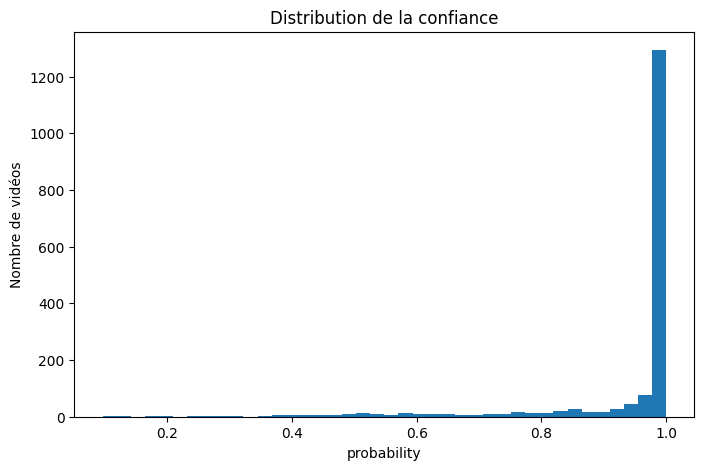

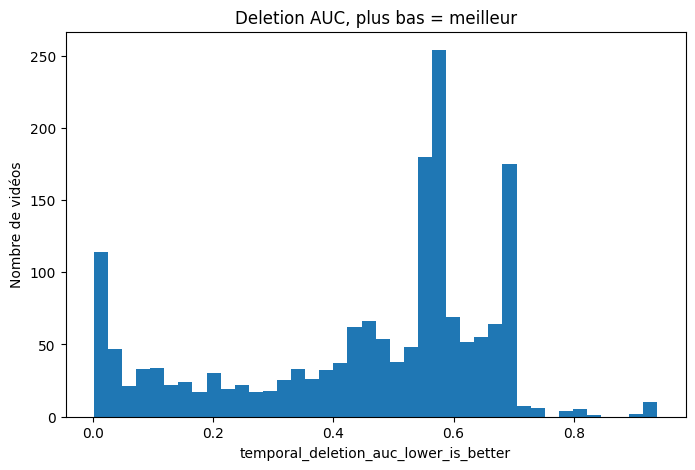

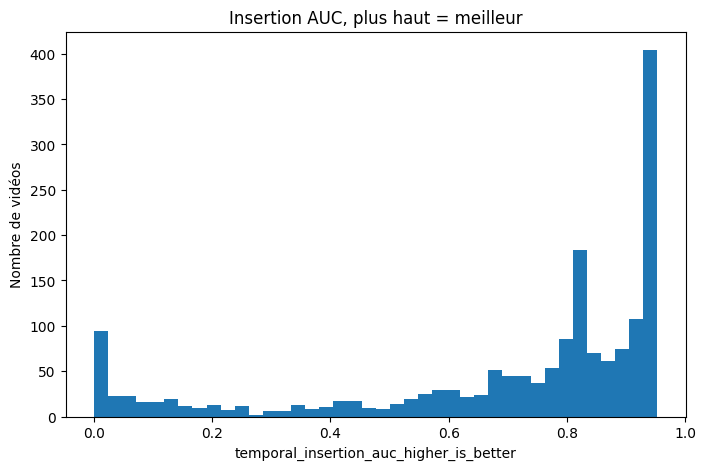

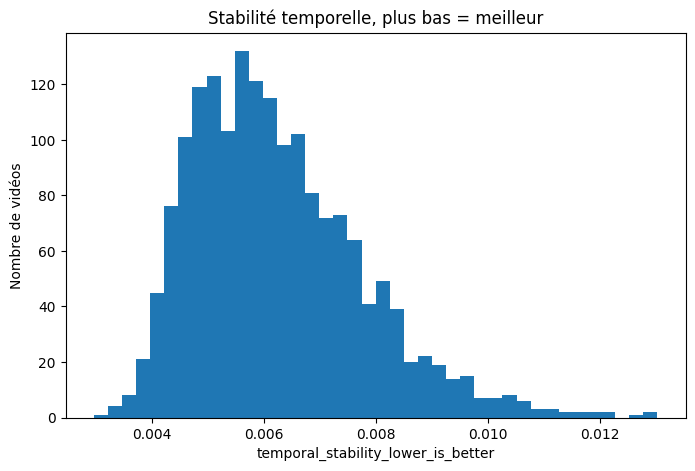

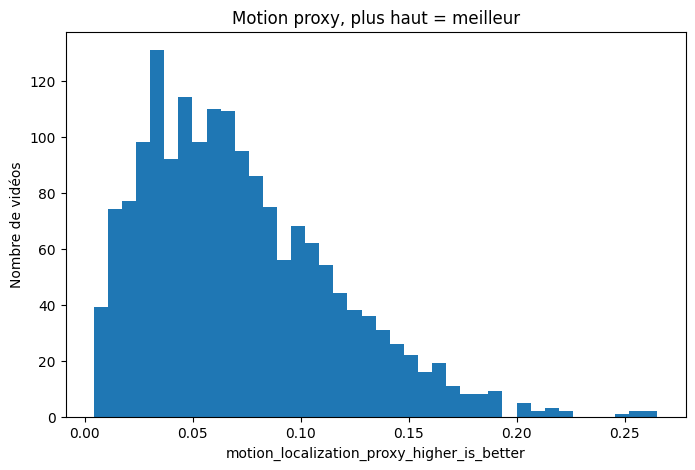

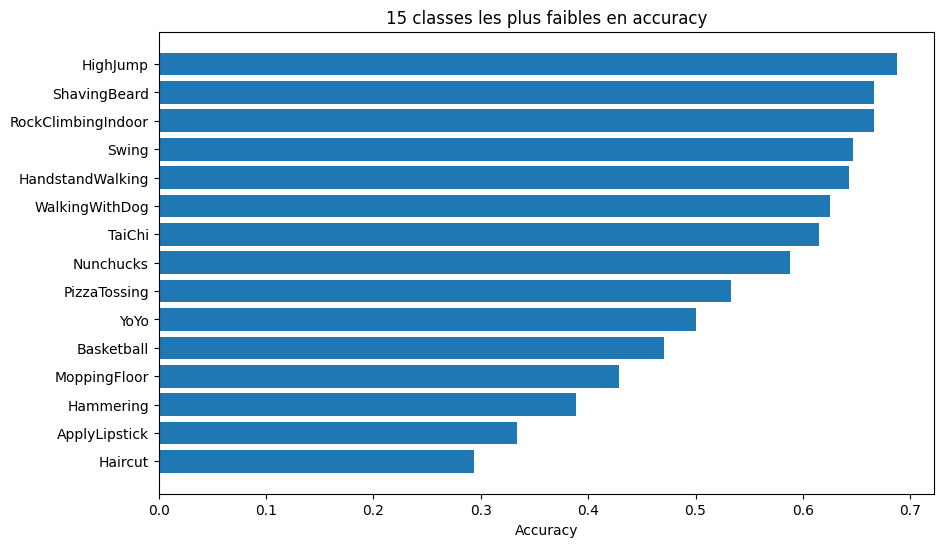

In [34]:
# Évaluation complète sur tout test
df_test = evaluate_full_split(checkpoint_path, split='test', max_samples=None)
summary_df, class_summary = summarize_results(df_test)
plot_diagnostics(df_test, class_summary)